In [52]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

We will now perform cross-validation on a simulated data set.

(a) Generate a simulated data set as follows:

rng = np.random. default_rng (1)

x = rng.normal(size =100)

y = x - 2 * x**2 + rng.normal(size =100)

In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

In [50]:
rng = np.random. default_rng (1)
x = rng.normal(size =100)
y = x - 2 * x**2 + rng.normal(size =100)

since size = 100, n = 100. And y only related to one variable x, so p = 1.

The equation : 

$$ y = x - 2x^2 + \epsilon $$

(b) Create a scatterplot of X against Y . Comment on what you find.

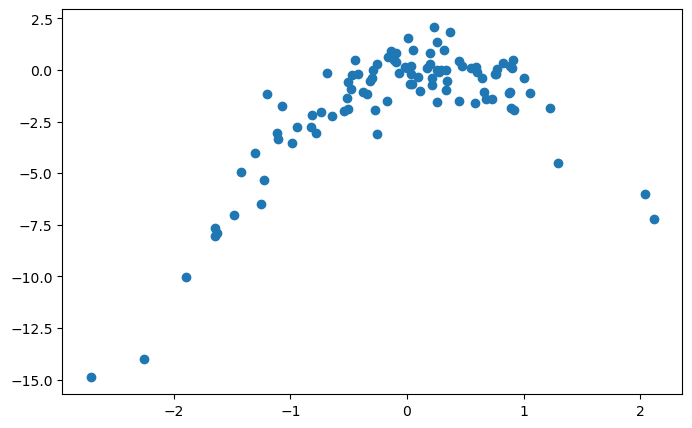

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.show()

It shows a parabola opening downward with the maximum y around x = 0.

(c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. $Y = \beta_0 + \beta_1 X + \epsilon$

ii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$

iii. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon$

iv. $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \epsilon$

Note you may find it helpful to use the $\text{data.frame()}$ function to create a single data set containing both $X$ and $Y$.

In [43]:
df = pd.DataFrame({"X": x, "Y": y})

def loocv_mse_with_cv(df, degree):
    X_raw = df[["X"]].values
    y = df["Y"].values

    # 建議: include_bias=False，讓 LinearRegression 自行估 intercept
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X = poly.fit_transform(X_raw)

    model = LinearRegression()  # fit_intercept=True by default
    loo = LeaveOneOut()
    # cross_val_score returns negative MSE if scoring='neg_mean_squared_error'
    scores = cross_val_score(model, X, y, cv=loo, scoring='neg_mean_squared_error')
    # 平均 MSE (取負號)
    mse = -scores.mean()
    return mse

degrees = [1,2,3,4]
results = {d: loocv_mse_with_cv(df, d) for d in degrees}
results

{1: np.float64(6.633029839181983),
 2: np.float64(1.1229368563419682),
 3: np.float64(1.301796548935888),
 4: np.float64(1.3323942694179285)}

(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [48]:
rng2 = np.random.default_rng(4)
x2 = rng2.normal(size =100)
y2 = x2 - 2 * x2**2 + rng2.normal(size =100)

df2 = pd.DataFrame({'X': x2, 'Y': y2})

results2 = {d: loocv_mse_with_cv(df2, d) for d in degrees}
results2

{1: np.float64(8.176486296276607),
 2: np.float64(0.9523097704784756),
 3: np.float64(0.9669997290056394),
 4: np.float64(0.9829150150228455)}

No, the results are different. Because they are based on different data set. Both of the lowest  LOOCV errors appear when degree = 2.

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

Degree 2 had the smallest LOOCV MSE error. it is what I expected because y is constructed as a Second-degree polynomial in x.

(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [54]:
def fit_statsmodels(x, y, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X = poly.fit_transform(x.reshape(-1,1))
    model = sm.OLS(y, X).fit()
    return model

model1 = fit_statsmodels(x, y, 1)
model2 = fit_statsmodels(x, y, 2)
model3 = fit_statsmodels(x, y, 3)
model4 = fit_statsmodels(x, y, 4)

print(model1.summary())
print(model2.summary())
print(model3.summary())
print(model4.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        01:09:49   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.0

Across the four polynomial models, the statistical significance of the coefficients shows a clear pattern.  
In the linear model (degree 1), the slope coefficient is highly significant (p < 0.001).  
For the quadratic model (degree 2), both the \(x\) and \(x^2\) terms are strongly significant, indicating strong evidence for a quadratic relationship.

In contrast, in the cubic model (degree 3), the \(x^3\) term is not statistically significant (p = 0.287).  
Similarly, in the quartic model (degree 4), the \(x^3\) term remains insignificant, and only the \(x^4\) term is marginally significant (p = 0.023).  
This suggests that adding higher-order terms beyond degree 2 does not substantially improve the model and likely captures noise rather than true structure.

These results are consistent with the cross-validation findings: the CV error drops sharply from degree 1 to degree 2, but the improvements from degrees 3 and 4 are small.  
Thus, the statistical significance analysis and the cross-validation conclusions agree that a quadratic model is sufficient and that higher-degree models offer little additional benefit.
